In [1]:
#import statements and formatting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from itertools import combinations
import matplotlib.ticker as mtick

plt.rcParams['pdf.fonttype'] = 42
sns.set(style="whitegrid", context="talk")

#load data
file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name = "Fig_1F+J_Extended_1B")


<h2>Fig 1E</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9159/436048785.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9159/436048785.py:20: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.8`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


NameError: name 'genotype_order' is not defined

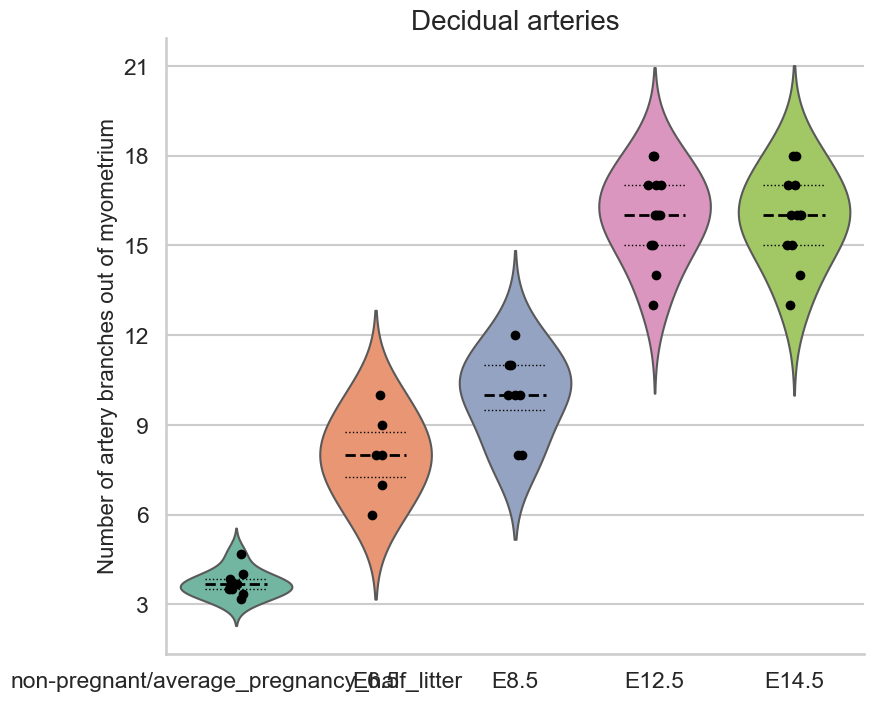

In [2]:
genotype_order_1e = ["non-pregnant/average_pregnancy_half_litter","E6.5", "E8.5", "E12.5", "E14.5"]

df_1e = df[genotype_order_1e]

plot_data = df.melt(
    value_vars=genotype_order_1e,
    var_name="embryonic_stage",
    value_name="artery number"
).dropna()

plot_data["embryonic_stage"] = pd.Categorical(
    plot_data["embryonic_stage"],
    categories=genotype_order_1e,
    ordered=True
)

palette = sns.color_palette("Set2", len(genotype_order_1e))
plt.figure(figsize=(9, 8))
ax = plt.gca()
sns.violinplot(
    data=plot_data,
    x="embryonic_stage",
    y="artery number",
    order=genotype_order_1e,
    inner=None,             
    linewidth=1.5,
    bw=0.8,                 
    cut=2.5,                
    palette=palette,
    ax=ax
)

group_stats = (
    plot_data.groupby("embryonic_stage")["artery number"]
    .agg(["median", "quantile"])
)

for i, g in enumerate(genotype_order_1e):
    vals = plot_data.loc[plot_data["embryonic_stage"] == g, "artery number"]
    median = vals.median()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)

    ax.hlines(
        median, i - 0.22, i + 0.22,
        colors="black",
        linestyles="dashed",
        linewidth=2,
        zorder=5
    )

    ax.hlines(
        [q1, q3], i - 0.22, i + 0.22,
        colors="black",
        linestyles="dotted",
        linewidth=1.,
        zorder=5
    )


sns.stripplot(
    data=plot_data,
    x="embryonic_stage",
    y="artery number",
    order=genotype_order_1e,
    color="black",
    size=7,
    jitter=0.05,
    zorder=6,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Number of artery branches out of myometrium", fontsize=16)
ax.set_title("Decidual arteries", fontsize=20)
sns.despine()
import matplotlib.ticker as mtick

ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))


groups = [plot_data.loc[plot_data["embryonic_stage"] == g, "artery number"]
          for g in genotype_order]
kw_stat, kw_p = kruskal(*groups)

if kw_p < 0.001:
    global_stars = "***"
elif kw_p < 0.01:
    global_stars = "**"
elif kw_p < 0.05:
    global_stars = "*"
else:
    global_stars = "ns"

ymax = plot_data["artery number"].max()
offset = ymax * 0.15

ax.text(
    1,
    ymax + offset * 0.25,
    f"Kruskal–Wallis p = {kw_p:.3g} ({global_stars})",
    ha='center', va='bottom', fontsize=14
)

dunn = sp.posthoc_dunn(
    plot_data,
    val_col="artery number",
    group_col="embryonic_stage",
    p_adjust="bonferroni"
)

pairs = list(combinations(genotype_order_1e, 2))
current_height = ymax + offset * 0.45
step = offset * 0.30

for (g1, g2) in pairs:
    pval = dunn.loc[g1, g2]

    if pval < 0.001:
        stars = "***"
    elif pval < 0.01:
        stars = "**"
    elif pval < 0.05:
        stars = "*"
    else:
        stars = "ns"

    x1 = genotype_order_1e.index(g1)
    x2 = genotype_order_1e.index(g2)

    ax.plot(
        [x1, x1, x2, x2],
        [current_height,
         current_height + offset * 0.1,
         current_height + offset * 0.1,
         current_height],
        color="black",
        lw=1.6
    )

    ax.text(
        (x1 + x2) / 2,
        current_height + offset * 0.12,
        stars,
        ha='center', va='bottom', fontsize=14
    )

    current_height += step

plt.tight_layout()
plt.show()

<h2>Fig 1I</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9159/4004392200.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9159/4004392200.py:20: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.8`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


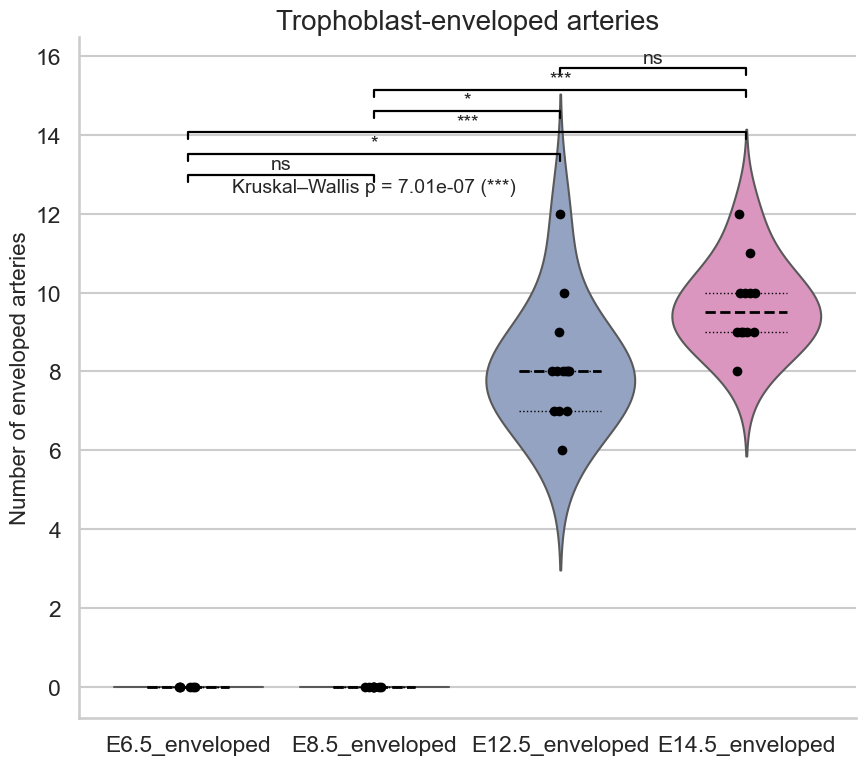

In [3]:
genotype_order_1i = ["E6.5_enveloped", "E8.5_enveloped", "E12.5_enveloped", "E14.5_enveloped"]

df_1i = df[genotype_order_1i]

plot_data = df.melt(
    value_vars=genotype_order_1i,
    var_name="embryonic_stage",
    value_name="artery number"
).dropna()

plot_data["embryonic_stage"] = pd.Categorical(
    plot_data["embryonic_stage"],
    categories=genotype_order_1i,
    ordered=True
)

palette = sns.color_palette("Set2", len(genotype_order_1i))
plt.figure(figsize=(9, 8))
ax = plt.gca()
sns.violinplot(
    data=plot_data,
    x="embryonic_stage",
    y="artery number",
    order=genotype_order_1i,
    inner=None,             
    linewidth=1.5,
    bw=0.8,                 
    cut=2.5,                
    palette=palette,
    ax=ax
)

group_stats = (
    plot_data.groupby("embryonic_stage")["artery number"]
    .agg(["median", "quantile"])
)

for i, g in enumerate(genotype_order_1i):
    vals = plot_data.loc[plot_data["embryonic_stage"] == g, "artery number"]
    median = vals.median()
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)

    ax.hlines(
        median, i - 0.22, i + 0.22,
        colors="black",
        linestyles="dashed",
        linewidth=2,
        zorder=5
    )

    ax.hlines(
        [q1, q3], i - 0.22, i + 0.22,
        colors="black",
        linestyles="dotted",
        linewidth=1.,
        zorder=5
    )


sns.stripplot(
    data=plot_data,
    x="embryonic_stage",
    y="artery number",
    order=genotype_order_1i,
    color="black",
    size=7,
    jitter=0.05,
    zorder=6,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Number of enveloped arteries", fontsize=16)
ax.set_title("Trophoblast-enveloped arteries", fontsize=20)
sns.despine()
import matplotlib.ticker as mtick

ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))


groups = [plot_data.loc[plot_data["embryonic_stage"] == g, "artery number"]
          for g in genotype_order_1i]
kw_stat, kw_p = kruskal(*groups)

if kw_p < 0.001:
    global_stars = "***"
elif kw_p < 0.01:
    global_stars = "**"
elif kw_p < 0.05:
    global_stars = "*"
else:
    global_stars = "ns"

ymax = plot_data["artery number"].max()
offset = ymax * 0.15

ax.text(
    1,
    ymax + offset * 0.25,
    f"Kruskal–Wallis p = {kw_p:.3g} ({global_stars})",
    ha='center', va='bottom', fontsize=14
)

dunn = sp.posthoc_dunn(
    plot_data,
    val_col="artery number",
    group_col="embryonic_stage",
    p_adjust="bonferroni"
)

pairs = list(combinations(genotype_order_1i, 2))
current_height = ymax + offset * 0.45
step = offset * 0.30

for (g1, g2) in pairs:
    pval = dunn.loc[g1, g2]

    if pval < 0.001:
        stars = "***"
    elif pval < 0.01:
        stars = "**"
    elif pval < 0.05:
        stars = "*"
    else:
        stars = "ns"

    x1 = genotype_order_1i.index(g1)
    x2 = genotype_order_1i.index(g2)

    ax.plot(
        [x1, x1, x2, x2],
        [current_height,
         current_height + offset * 0.1,
         current_height + offset * 0.1,
         current_height],
        color="black",
        lw=1.6
    )

    ax.text(
        (x1 + x2) / 2,
        current_height + offset * 0.12,
        stars,
        ha='center', va='bottom', fontsize=14
    )

    current_height += step

plt.tight_layout()
plt.show()

<h2>Extended Data Figure 1B</h2>

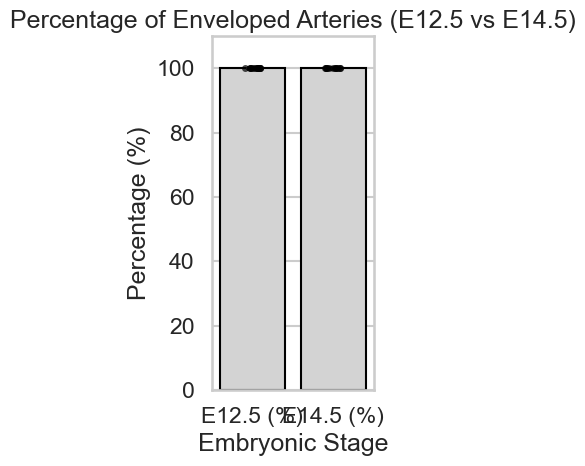

In [4]:
# Calculate the percentages for E12.5 and E14.5
df['E12.5 (%)'] = (df['E12.5_enveloped'] / df['E12.5_enveloped_enter']) * 100
df['E14.5 (%)'] = (df['E14.5_enveloped'] / df['E14.5_enveloped_enter']) * 100

# Melt the dataframe to prepare it for Seaborn 
plot_data = df[['E12.5 (%)', 'E14.5 (%)']].melt(var_name='Stage', value_name='Percentage')

# Drop missing values
plot_data = plot_data.dropna()

# Initialize the plot
plt.figure(figsize=(3, 5))

# Create a barplot to show the mean and standard deviation ('sd')
sns.barplot(
    data=plot_data, 
    x='Stage', 
    y='Percentage', 
    color='lightgray', 
    edgecolor='black', 
    errorbar='sd', 
    capsize=0.1
)

# Overlay individual data points
sns.stripplot(
    data=plot_data, 
    x='Stage', 
    y='Percentage', 
    color='black', 
    alpha=0.7, 
    jitter=True
)

# Add titles and labels
plt.title('Percentage of Enveloped Arteries (E12.5 vs E14.5)')
plt.ylabel('Percentage (%)')
plt.xlabel('Embryonic Stage')

# Set Y-axis limits slightly above 100
plt.ylim(0, 110)
plt.tight_layout()

# Save and show the plot
plt.savefig('enveloped_percentage_bar_comparison.pdf')
plt.show()